In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("Arrest_Data_from_2010_to_2019.csv")
df.columns = df.columns.str.strip()
df["Arrest Date"] = pd.to_datetime(df["Arrest Date"], errors="coerce")
df["Year"] = df["Arrest Date"].dt.year

In [170]:
df_1 = df[df['Arrest Date'] >= '2018-01-01'].copy()
df_2018 = df_1[df_1['Year'] == 2018].copy()

print(len(df_2018))


104277


In [171]:
area = df_2018['Area Name'].value_counts()
print(f"{area.idxmax()} has {area.max()} reports")

Central has 10951 reports


In [172]:
groups = ['Vehicle Theft', 'Robbery','Burglary','Receive Stolen Property']
df_2018_Charge = df_2018[df_2018['Charge Group Description'].isin(groups)].copy()
print(df_2018_Charge['Age'].quantile(0.95))


52.0


In [173]:
excluded = ['Pre-Delinquency','Non-Criminal Detention']
df_2018_ztest = df_2018[~df_2018['Charge Group Description'].isin(excluded) & df_2018["Charge Group Description"].notna()].copy()

group_avg = df_2018_ztest.groupby('Charge Group Description')["Age"].mean()

z_scores = abs((group_avg-group_avg.mean()) / group_avg.std())

print(f"{z_scores.idxmax()} has the largest absolute value of {z_scores.max()}")

Drunkeness has the largest absolute value of 2.1278699344353633


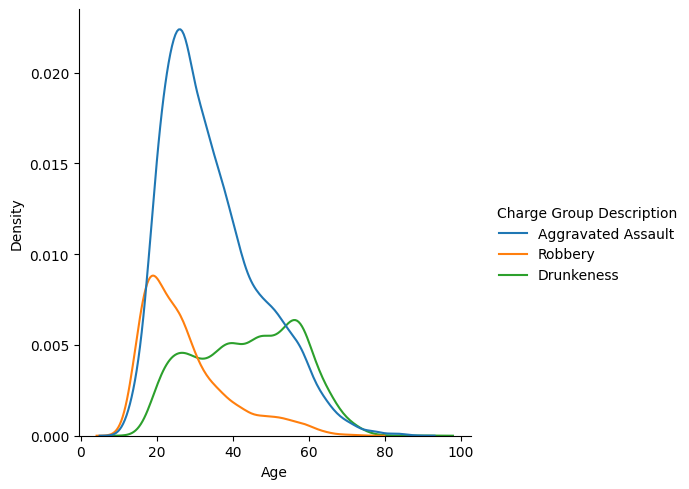

In [174]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_groups = ['Drunkeness', 'Robbery', 'Aggravated Assault']
filtered_df = df_2018_ztest[df_2018_ztest['Charge Group Description'].isin(sample_groups)]

sns.displot(data=filtered_df, x="Age", hue="Charge Group Description", kind="kde")
plt.show()

In [175]:
groups = [group['Age'].values 
          for q, group in df_2018_ztest.groupby('Charge Group Description')]


stat, p_value = stats.kruskal(*groups)
print(stat)
print(f"{p_value:.2e}")

6658.412909130706
0.00e+00


In [176]:
lat = 34.050536
long = -118.247861
earth_radius = 6371
within = 2

def distance(lat1,lon1,lat2,lon2,r = earth_radius):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    return r*np.sqrt(((lat2-lat1)*np.cos((lon2-lon1)/2))**2 + (2*np.cos((lat1+lat2)/2)*np.sin((lon2-lon1)/2))**2)

split_cords = df_2018["Location"].str.strip("()").str.split(",",expand=True)
df_2018['LAT'] = split_cords[0].astype(float)
df_2018['LONG'] = split_cords[1].astype(float)

df_q5 = df_2018[(df_2018['LAT'] !=0) & (df_2018['LONG'] !=0) & (df_2018['LAT'].notna()) & df_2018['LONG'].notna()].copy()

df_q5['dist'] = distance(df_q5['LAT'].values, df_q5['LONG'].values, lat,long, earth_radius)

print((df_q5['dist'] <=2).sum())

11461


In [177]:
df_2018_pico = df_2018[df_2018['Address'].str.contains("PICO",na=False,case=False)].copy()

m1 = df_2018_pico['LAT'].mean()
m2 = df_2018_pico['LONG'].mean()
std1 = df_2018_pico['LAT'].std()
std2 = df_2018_pico['LONG'].std()

df_2018_pico = df_2018_pico[df_2018_pico['LAT'].between(m1-2*std1,m1+2*std1) & 
                            df_2018_pico['LONG'].between(m2-2*std2,m2+2*std2)]

west = df_2018_pico.loc[df_2018_pico['LONG'].idxmin()]
east = df_2018_pico.loc[df_2018_pico['LONG'].idxmax()]

pico_distance = distance(west['LAT'],west['LONG'],east['LAT'],east['LONG'])

arrests_per_kilometer = len(df_2018_pico)/pico_distance

print(arrests_per_kilometer)


27.6566189063149


In [ ]:
df_prior_2019 = df[(df['Arrest Date'] < '2019-01-01') & (df['Charge Group Code'].notna() & (df['Charge Group Code'] != 99))].copy()

probability_unconditional = df_prior_2019['Charge Group Code'].value_counts()/ len(df_prior_2019)

areas_numberofincidents = df_prior_2019.groupby("Area ID").size()
joint = df_prior_2019.groupby(["Area ID", "Charge Group Code"]).size()
probability_conditional = joint.div(areas_numberofincidents,axis=0)

ratios = probability_conditional.div(probability_unconditional, level="Charge Group Code")

print(ratios.nlargest(5).mean())

3.515076379865202


In [304]:
from sklearn.linear_model import LinearRegression

df_q8 = df[(df['Arrest Date'] < '2019-01-01') & (df['Arrest Date'] >= '2010-01-01') & (df['Arrest Type Code'] == "F")].copy()

values = df_q8.groupby('Year').size()

x = []
y = []
for year, value in values.items():
    x.append([year])
    y.append(value)

model = LinearRegression()
model.fit(x,y)
print(round(model.predict([[2019]])[0]))


31038
